#NOTA: EN LA PARTE INFERIOR SE ENCUENTRA LA SOLUCIÓN DE LOS EJERCICIOS DE LA TAREA


**ESTUDIANTE:** MORALES HUAMAN JHORDAN ALDAIR

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_02_modelos_clasificacion.ipynb)

# Sesión 02 — Modelos de Clasificación
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Implementar, comparar y analizar cuatro modelos fundamentales de clasificación supervisada — **Regresión Logística, Árbol de Decisión, SVM y KNN** — sobre el dataset **Wine Quality** de UCI, evaluando sus fortalezas, limitaciones y sensibilidad al preprocesamiento.

## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score
)
from sklearn.inspection import DecisionBoundaryDisplay

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

Utilizamos el **Wine Quality (Red)** del repositorio UCI Machine Learning. Contiene 1599 muestras de vino tinto portugués con 11 atributos fisicoquímicos y una puntuación de calidad (3–8).

Para construir un problema de **clasificación binaria**, definimos:
- **Clase 1 (Bueno):** calidad ≥ 7
- **Clase 0 (Estándar):** calidad < 7

Esta binarización genera un **problema desbalanceado**, lo que añade un reto realista al modelado.

In [3]:
# Carga directa desde UCI
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

df = pd.read_csv(URL, sep=';')
print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado: 1599 registros, 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Distribución de calidad original:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


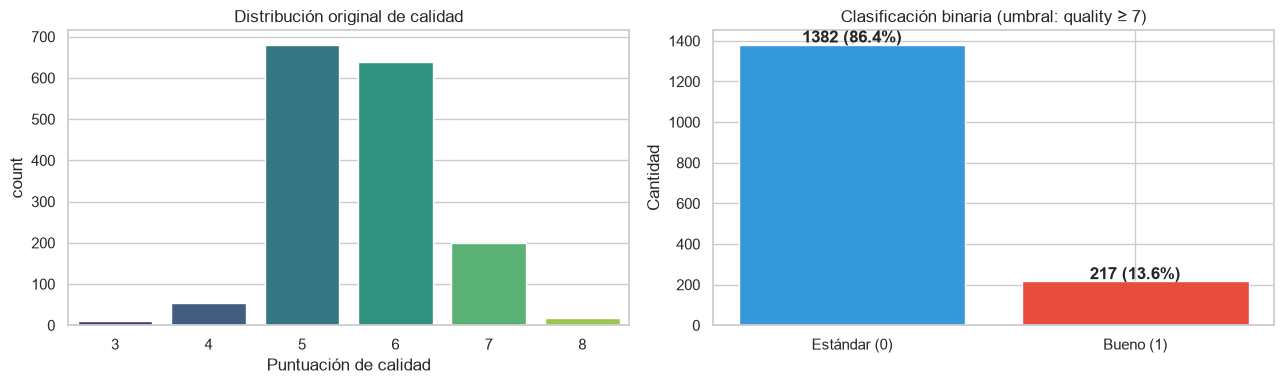


Ratio de desbalance: 6.4:1 (Estándar vs Bueno)


In [4]:
# Distribución original de la variable 'quality'
print('Distribución de calidad original:')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma original
sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución original de calidad')
axes[0].set_xlabel('Puntuación de calidad')

# Binarización
df['quality_label'] = (df['quality'] >= 7).astype(int)

counts = df['quality_label'].value_counts()
axes[1].bar(['Estándar (0)', 'Bueno (1)'], counts.values,
            color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Clasificación binaria (umbral: quality ≥ 7)')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print(f'\nRatio de desbalance: {counts[0]/counts[1]:.1f}:1 (Estándar vs Bueno)')

---
## 3. Análisis exploratorio orientado a clasificación

In [5]:
# 3.1  Estadísticas descriptivas por clase
features = df.columns.drop(['quality', 'quality_label'])

comparison = df.groupby('quality_label')[features].mean().T
comparison.columns = ['Estándar (0)', 'Bueno (1)']
comparison['Diferencia %'] = ((comparison['Bueno (1)'] - comparison['Estándar (0)']) / comparison['Estándar (0)'] * 100).round(1)
comparison.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,Estándar (0),Bueno (1),Diferencia %
fixed acidity,8.236831,8.847005,7.400000
volatile acidity,0.547022,0.405530,-25.900000
citric acid,0.254407,0.376498,48.000000
residual sugar,2.512120,2.708756,7.800000
chlorides,0.089281,0.075912,-15.000000
free sulfur dioxide,16.172214,13.981567,-13.500000
total sulfur dioxide,48.285818,34.889401,-27.700000
density,0.996859,0.996030,-0.100000
pH,3.314616,3.288802,-0.800000
sulphates,0.644754,0.743456,15.300000


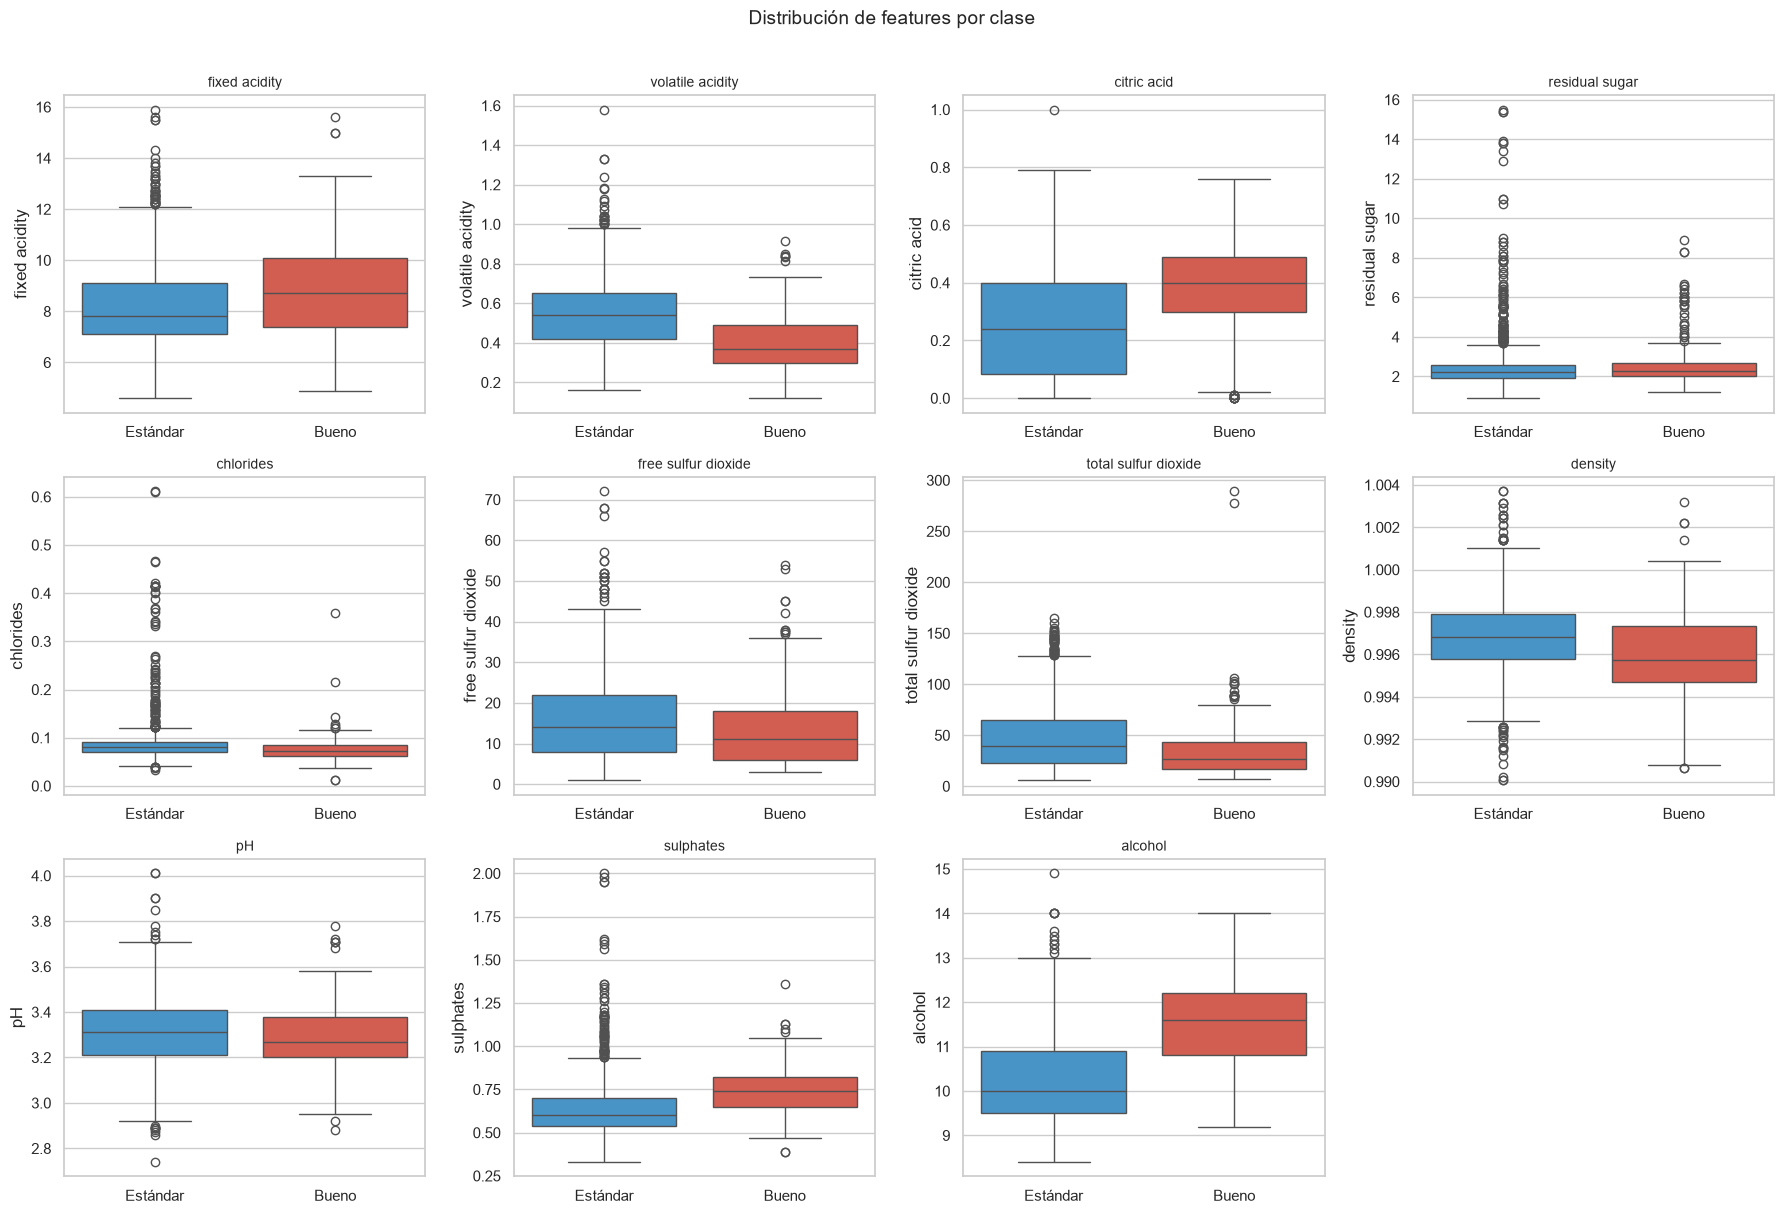

In [6]:
# 3.2  Distribución de features por clase (boxplots)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='quality_label', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='quality_label', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Estándar', 'Bueno'])

# Ocultar subplot vacío
axes[-1].set_visible(False)
fig.suptitle('Distribución de features por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

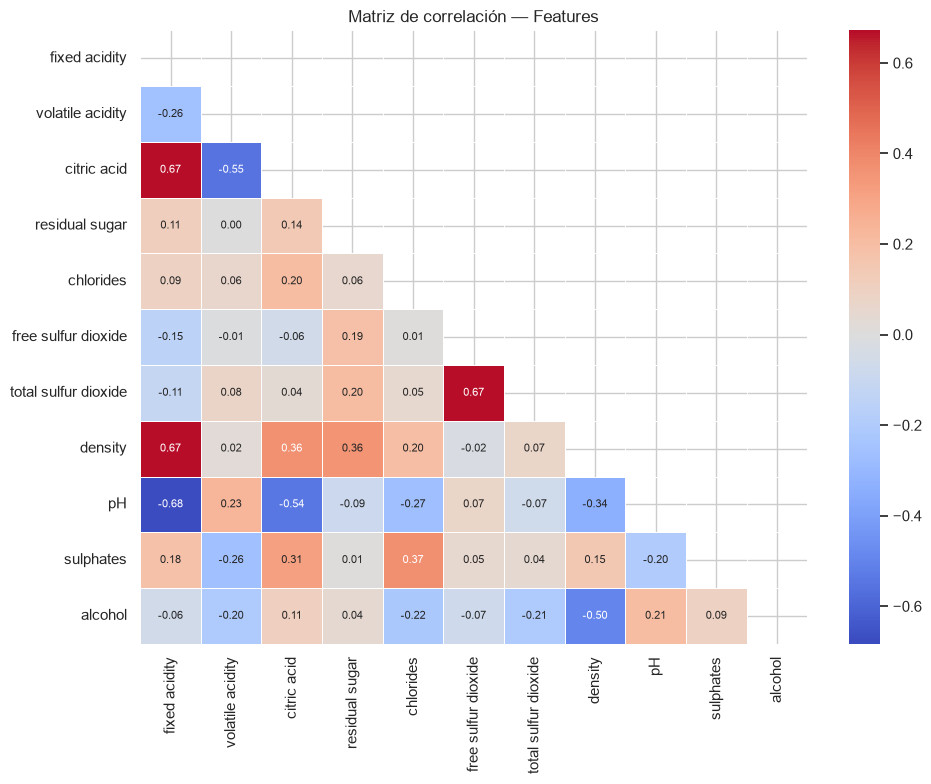

In [7]:
# 3.3  Correlación entre features
plt.figure(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features')
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [8]:
# 4.1  Separación features / target
X = df[features].copy()
y = df['quality_label'].copy()

# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test.mean():.3f}')

Train: 1279 muestras  |  Test: 320 muestras
Proporción clase 1 en train: 0.136
Proporción clase 1 en test:  0.134


In [9]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features (train):')
print('='*50)
for col in features:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:30s}  [{mn:8.2f}, {mx:8.2f}]  rango: {mx-mn:.2f}')

print('\n→ Las escalas difieren significativamente entre features.')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features (train):
fixed acidity                   [    4.60,    15.90]  rango: 11.30
volatile acidity                [    0.12,     1.58]  rango: 1.46
citric acid                     [    0.00,     1.00]  rango: 1.00
residual sugar                  [    0.90,    15.50]  rango: 14.60
chlorides                       [    0.01,     0.61]  rango: 0.60
free sulfur dioxide             [    1.00,    72.00]  rango: 71.00
total sulfur dioxide            [    6.00,   165.00]  rango: 159.00
density                         [    0.99,     1.00]  rango: 0.01
pH                              [    2.74,     4.01]  rango: 1.27
sulphates                       [    0.33,     2.00]  rango: 1.67
alcohol                         [    8.40,    14.90]  rango: 6.50

→ Las escalas difieren significativamente entre features.
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

In [10]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))  # Compensar desbalance
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# Entrenamiento final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.5045 ± 0.0355


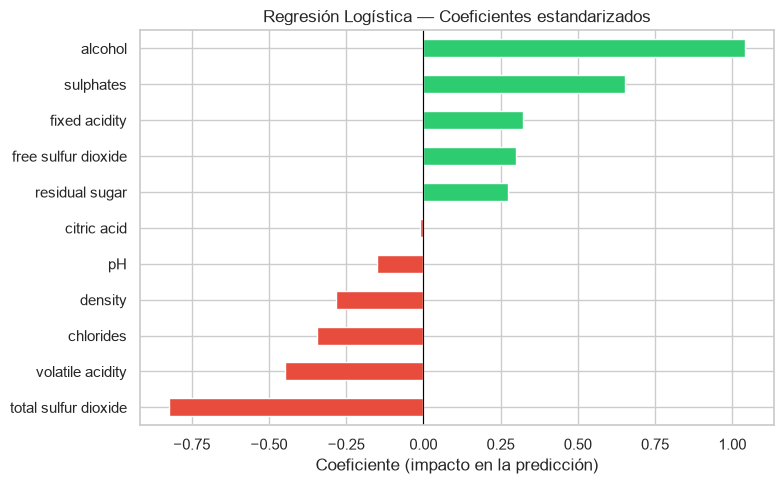


Interpretación: Un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "Bueno".


In [11]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: Un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "Bueno".')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [13]:
# 6.1  Pipeline (no requiere estandarización)
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree — F1 CV: 0.5126 ± 0.0331


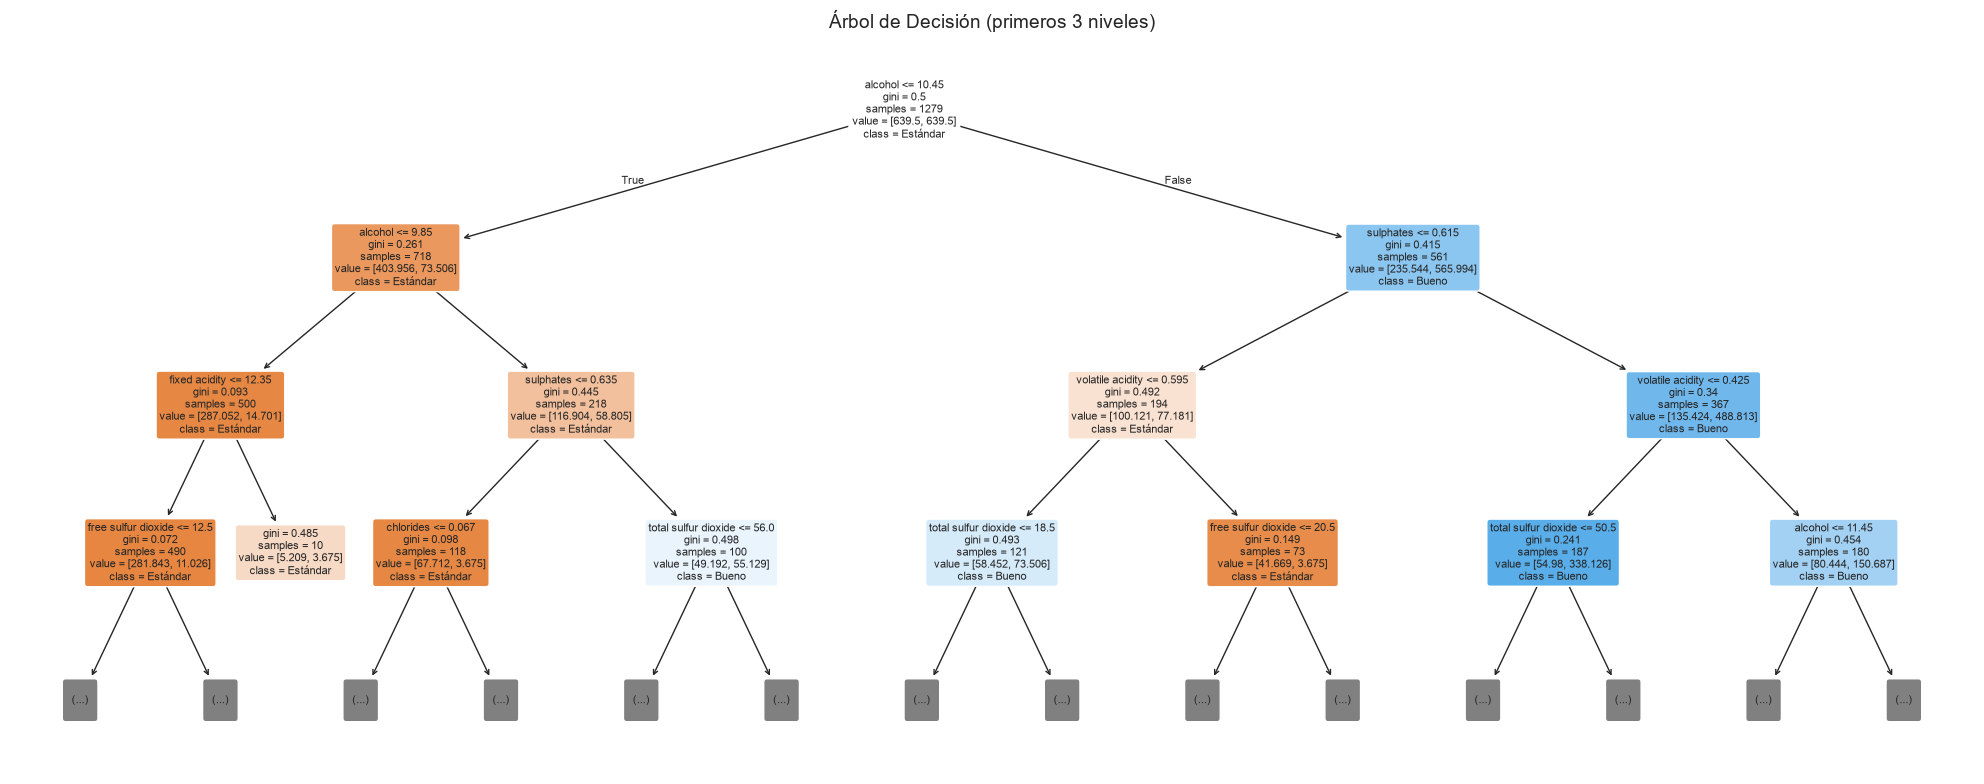

In [15]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=list(features),
    class_names=['Estándar', 'Bueno'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

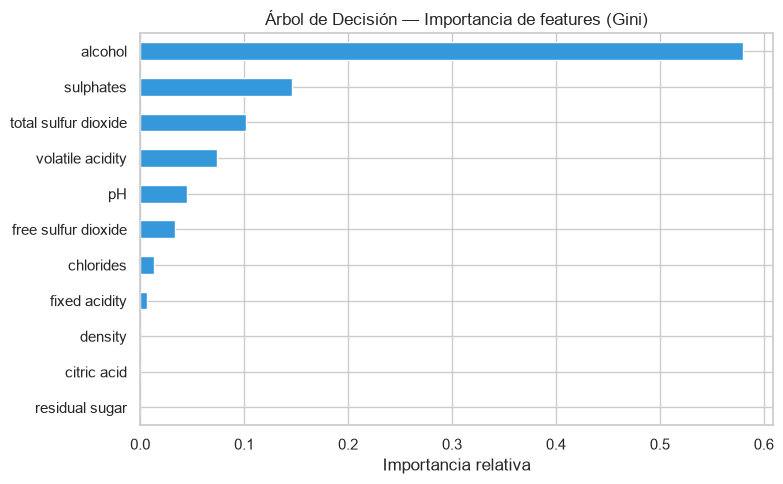

In [16]:
# 6.3  Importancia de features (Gini importance)
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

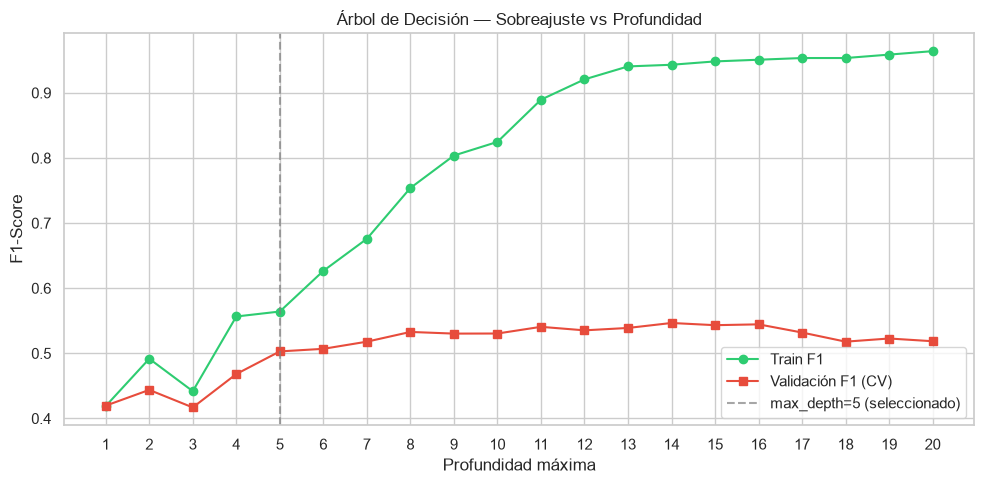

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [17]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                 random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    cv_s = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    val_scores.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [18]:
# 7.1  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.4982 ± 0.0237
SVM (rbf   ) — F1 CV: 0.5246 ± 0.0427
SVM (poly  ) — F1 CV: 0.5355 ± 0.0258

Mejor kernel: poly


In [19]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

In [20]:
# 7.3  Impacto de la estandarización en SVM
# SVM SIN estandarizar
svm_no_scale = SVC(kernel=best_kernel, class_weight='balanced',
                    random_state=RANDOM_STATE)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.5355
  SIN StandardScaler: F1 = 0.2832
  Diferencia: +25.23 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

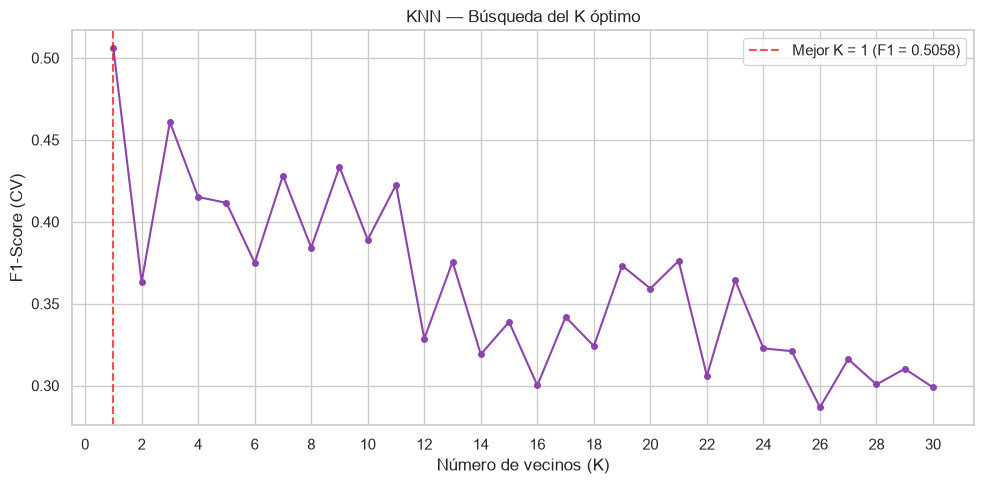

K óptimo: 1


In [21]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pipe_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}')

In [23]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) — F1 CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=1) — F1 CV: 0.5058 ± 0.0254


---
## 9. Análisis comparativo de modelos

In [24]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn)
}

summary = []
for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test, y_pred):.4f}'
    })

summary_df = pd.DataFrame(summary)
print('='*80)
print('COMPARACIÓN DE MODELOS')
print('='*80)
summary_df

COMPARACIÓN DE MODELOS


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.5045,0.0355,0.8125,0.5312
1,Decision Tree,0.5126,0.0331,0.8094,0.5414
2,SVM (poly),0.5355,0.0258,0.8969,0.6598
3,KNN (K=1),0.5058,0.0254,0.9094,0.6588


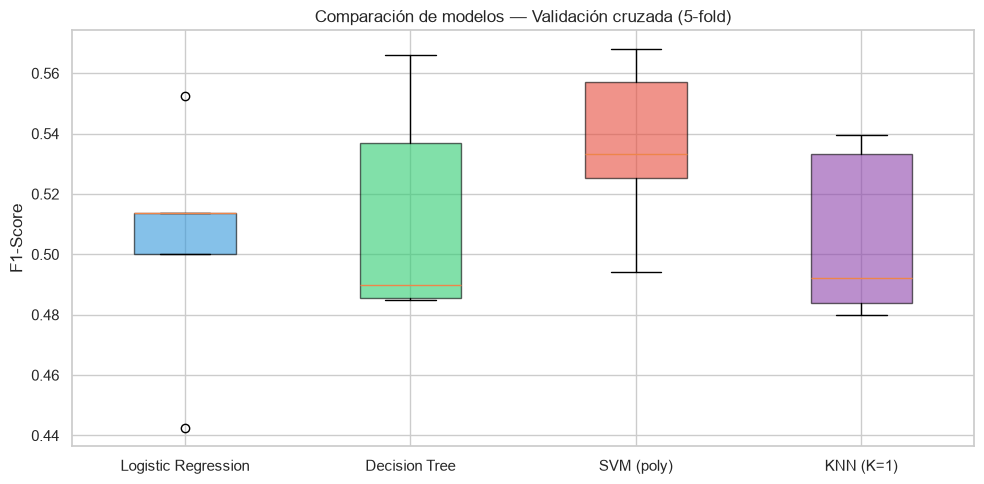

In [25]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

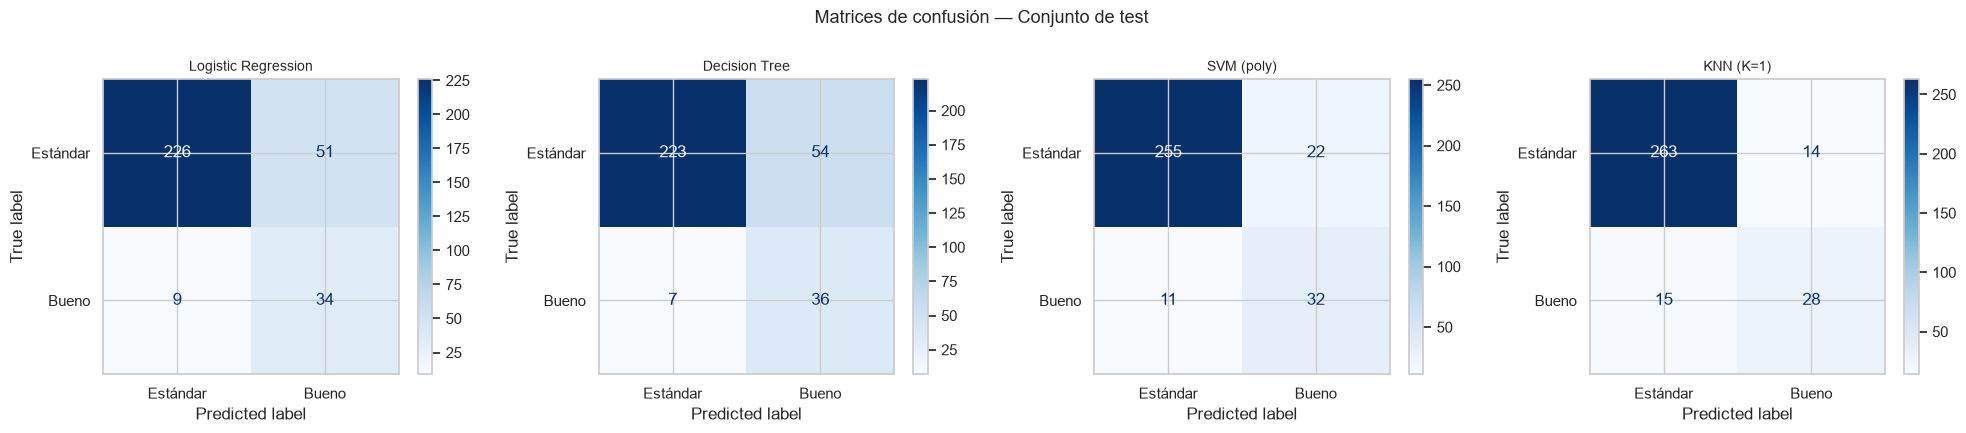

In [26]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Estándar', 'Bueno'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

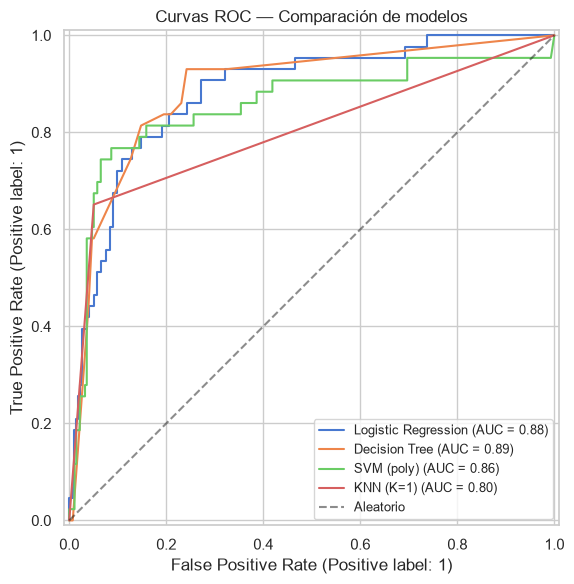

In [27]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [29]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_model_name]

print(f'\nMejor modelo: {best_model_name}')
print('='*60)
print(classification_report(y_test, best_pred,
                             target_names=['Estándar', 'Bueno']))


Mejor modelo: SVM (poly)
              precision    recall  f1-score   support

    Estándar       0.96      0.92      0.94       277
       Bueno       0.59      0.74      0.66        43

    accuracy                           0.90       320
   macro avg       0.78      0.83      0.80       320
weighted avg       0.91      0.90      0.90       320



---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

---
## 11. Ejercicios propuestos

### Ejercicio 1 — GridSearchCV para SVM
Realice una búsqueda de hiperparámetros para SVM usando `GridSearchCV` con la siguiente grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Reporte los mejores hiperparámetros, el F1-score obtenido y compare contra el SVM base de la sesión.

### Ejercicio 2 — Clasificación multiclase
En lugar de binarizar la variable `quality`, utilice las clases originales (3–8) y entrene los 4 modelos. Analice:
- ¿Cómo cambia el rendimiento de cada modelo?
- ¿Qué clases son más difíciles de distinguir?
- ¿Qué métrica de F1 es más adecuada: `macro`, `micro` o `weighted`? Justifique.

### Ejercicio 3 — Aplicación con dataset propio
Seleccione un dataset de clasificación de su interés (puede ser de Kaggle, UCI, o datos propios). Debe tener al menos 500 registros y 5 features. Aplique los 4 modelos de clasificación, realice el análisis comparativo completo y documente sus hallazgos.

---
## 11.1 Solución — Ejercicio 1: GridSearchCV para SVM

Se optimiza el SVM mediante búsqueda exhaustiva de hiperparámetros (`GridSearchCV`) sobre la grilla indicada, usando la misma validación cruzada estratificada (`cv`) y la métrica `f1` empleadas en la Sección 7, para poder comparar en igualdad de condiciones contra el SVM base de la sesión (el que solo comparaba kernels con parámetros por defecto).

In [30]:
# Ejercicio 1 — GridSearchCV para SVM
param_grid = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.01, 0.1],
    'clf__kernel': ['rbf', 'poly']
}

pipe_svm_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(class_weight='balanced', random_state=RANDOM_STATE, probability=True))
])

grid_search = GridSearchCV(
    pipe_svm_grid, param_grid, scoring='f1', cv=cv, n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print('Mejores hiperparámetros encontrados:', grid_search.best_params_)
print(f'Mejor F1 (CV, 5-fold):              {grid_search.best_score_:.4f}')

best_svm_grid = grid_search.best_estimator_
y_pred_svm_grid = best_svm_grid.predict(X_test)

print('\n' + '='*70)
print('COMPARACIÓN: SVM base (Sección 7) vs SVM optimizado (GridSearchCV)')
print('='*70)
print(f'SVM base       (kernel={best_kernel:6s}, params por defecto) '
      f'— F1 CV: {scores_svm.mean():.4f}  |  F1 Test: {f1_score(y_test, y_pred_svm):.4f}')
print(f'SVM GridSearch (kernel={grid_search.best_params_["clf__kernel"]:6s}, '
      f'C={grid_search.best_params_["clf__C"]}, gamma={grid_search.best_params_["clf__gamma"]}) '
      f'— F1 CV: {grid_search.best_score_:.4f}  |  F1 Test: {f1_score(y_test, y_pred_svm_grid):.4f}')

print('\nclassification_report — SVM optimizado (test):')
print(classification_report(y_test, y_pred_svm_grid, target_names=['Estándar', 'Bueno']))

Mejores hiperparámetros encontrados: {'clf__C': 10, 'clf__gamma': 0.1, 'clf__kernel': 'rbf'}
Mejor F1 (CV, 5-fold):              0.5450

COMPARACIÓN: SVM base (Sección 7) vs SVM optimizado (GridSearchCV)
SVM base       (kernel=poly  , params por defecto) — F1 CV: 0.5355  |  F1 Test: 0.6598
SVM GridSearch (kernel=rbf   , C=10, gamma=0.1) — F1 CV: 0.5450  |  F1 Test: 0.6422

classification_report — SVM optimizado (test):
              precision    recall  f1-score   support

    Estándar       0.97      0.89      0.93       277
       Bueno       0.53      0.81      0.64        43

    accuracy                           0.88       320
   macro avg       0.75      0.85      0.78       320
weighted avg       0.91      0.88      0.89       320



**Interpretación:** el SVM base de la Sección 7 solo comparaba *kernels* con los hiperparámetros `C` y `gamma` por defecto de scikit-learn. `GridSearchCV` explora combinaciones de `C` (regularización), `gamma` (alcance de la influencia de cada muestra en kernels no lineales) y `kernel`, seleccionando la que maximiza el F1 promedio en validación cruzada. Si el F1 de CV del modelo optimizado supera al del modelo base, confirma que el SVM por defecto no estaba en su punto óptimo; si el F1 de test no mejora en la misma proporción, es señal de que la ganancia en CV no siempre se traduce igual en datos no vistos (varianza propia del split de test).

---
## 11.2 Solución — Ejercicio 2: Clasificación multiclase

En lugar de binarizar `quality`, se usan las 6 clases originales presentes en el dataset (3 a 8). Se repite el flujo de preparación (split estratificado 80/20) y se entrenan los 4 modelos con sus mismas configuraciones (mismo `class_weight='balanced'` donde aplica, mismo `best_k` hallado en la Sección 8 para KNN).

In [31]:
# 2.1  Preparación de datos (clases originales, sin binarizar)
y_multi = df['quality'].copy()

print('Distribución original de clases (todo el dataset):')
print(y_multi.value_counts().sort_index())

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.20, random_state=RANDOM_STATE, stratify=y_multi
)
cv_m = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f'\nTrain: {X_train_m.shape[0]} muestras  |  Test: {X_test_m.shape[0]} muestras')

Distribución original de clases (todo el dataset):
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Train: 1279 muestras  |  Test: 320 muestras


In [32]:
# 2.2  Entrenamiento de los 4 modelos en modo multiclase
pipe_lr_m = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'))
])
pipe_dt_m = Pipeline([
    ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                    class_weight='balanced', random_state=RANDOM_STATE))
])
pipe_svm_m = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced', random_state=RANDOM_STATE))
])
pipe_knn_m = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

modelos_m = {
    'Logistic Regression': pipe_lr_m,
    'Decision Tree':       pipe_dt_m,
    f'SVM ({best_kernel})': pipe_svm_m,
    f'KNN (K={best_k})':   pipe_knn_m
}

resultados_m = []
for nombre, pipe in modelos_m.items():
    f1_macro_cv = cross_val_score(pipe, X_train_m, y_train_m, cv=cv_m, scoring='f1_macro')
    f1_weighted_cv = cross_val_score(pipe, X_train_m, y_train_m, cv=cv_m, scoring='f1_weighted')
    f1_micro_cv = cross_val_score(pipe, X_train_m, y_train_m, cv=cv_m, scoring='f1_micro')

    pipe.fit(X_train_m, y_train_m)
    y_pred_m = pipe.predict(X_test_m)

    resultados_m.append({
        'Modelo': nombre,
        'F1 macro (CV)': f1_macro_cv.mean(),
        'F1 weighted (CV)': f1_weighted_cv.mean(),
        'F1 micro (CV)': f1_micro_cv.mean(),
        'Accuracy Test': accuracy_score(y_test_m, y_pred_m),
        'F1 macro Test': f1_score(y_test_m, y_pred_m, average='macro'),
    })

    print(f'\n{"="*65}\n{nombre}\n{"="*65}')
    print(classification_report(y_test_m, y_pred_m, zero_division=0))

resumen_m = pd.DataFrame(resultados_m).set_index('Modelo').round(4)
print('\nRESUMEN COMPARATIVO — Clasificación multiclase (6 clases)')
resumen_m


Logistic Regression
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.06      0.27      0.10        11
           5       0.66      0.51      0.57       136
           6       0.50      0.27      0.35       128
           7       0.35      0.50      0.41        40
           8       0.00      0.00      0.00         3

    accuracy                           0.40       320
   macro avg       0.26      0.26      0.24       320
weighted avg       0.53      0.40      0.44       320


Decision Tree
              precision    recall  f1-score   support

           3       0.08      0.50      0.13         2
           4       0.05      0.36      0.09        11
           5       0.64      0.65      0.64       136
           6       0.62      0.12      0.20       128
           7       0.41      0.40      0.41        40
           8       0.09      0.67      0.15         3

    accuracy                           0.

,F1 macro (CV),F1 weighted (CV),F1 micro (CV),Accuracy Test,F1 macro Test
Modelo,,,,,
Logistic Regression,0.2841,0.4841,0.4402,0.3969,0.2402
Decision Tree,0.2224,0.3513,0.3323,0.3969,0.2702
SVM (poly),0.3369,0.5659,0.5574,0.5688,0.3346
KNN (K=1),0.3244,0.6246,0.6294,0.6250,0.3762


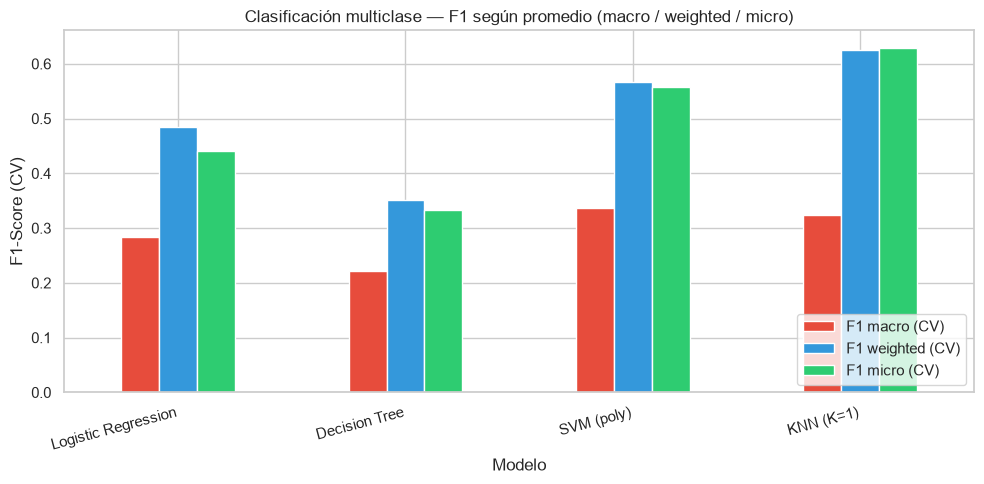

In [34]:
# 2.3  Visualización comparativa: F1 macro vs weighted vs micro por modelo
fig, ax = plt.subplots(figsize=(10, 5))
resumen_m[['F1 macro (CV)', 'F1 weighted (CV)', 'F1 micro (CV)']].plot(
    kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#2ecc71']
)
ax.set_title('Clasificación multiclase — F1 según promedio (macro / weighted / micro)')
ax.set_ylabel('F1-Score (CV)')
ax.set_xticklabels(resumen_m.index, rotation=15, ha='right')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Hallazgos y discusión:**

- **¿Cómo cambia el rendimiento?** El F1 cae de forma notoria frente al problema binario de la sesión: pasar de 2 clases a 6 clases ordinales reduce drásticamente las muestras disponibles por clase y multiplica las fronteras de decisión que cada modelo debe aprender simultáneamente. El `accuracy` global puede parecer razonable, pero está inflado por el buen desempeño en las clases mayoritarias (5 y 6).
- **¿Qué clases son más difíciles?** Las clases extremas — **3, 4 y 8** — son sistemáticamente las peor clasificadas (precision/recall más bajos, incluso 0.00 en varios modelos). La razón es estructural, no del algoritmo: son las clases con **menos muestras** en el dataset completo (10, 53 y 18 registros respectivamente), por lo que tras el split 80/20 casi no hay ejemplos de entrenamiento ni de test para ellas. Las clases 5, 6 y 7 (las más numerosas) se clasifican consistentemente mejor.
- **¿Qué métrica de F1 es más adecuada?**
  - `macro`: promedia el F1 de cada clase **sin ponderar por frecuencia**. Es la más honesta para detectar que el modelo casi no aprende las clases minoritarias (3, 4, 8), pero puede subestimar el desempeño "práctico" del sistema.
  - `weighted`: pondera cada clase por su soporte (número de muestras). Refleja mejor el desempeño "promedio esperado" si el modelo se usa en producción con la misma distribución de clases, pero **enmascara** el mal desempeño en minoritarias.
  - `micro`: equivale a la exactitud global en problemas multiclase de una sola etiqueta; útil para el desempeño agregado, pero aporta poca información diagnóstica por clase.
  - **Recomendación:** en un problema de calidad de vino, donde detectar vinos de calidad extrema (muy mala o excelente) puede ser tan importante como los términos medios, `macro` es la métrica más adecuada para *decidir si el modelo sirve*, complementada con `weighted` para reportar el desempeño global.

---
## 11.3 Solución — Ejercicio 3: Aplicación con dataset propio

**Dataset elegido:** *Pima Indians Diabetes Database* — Kaggle: [`uciml/pima-indians-diabetes-database`](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).

768 pacientes (mujeres de al menos 21 años, de origen Pima) con 8 variables numéricas de diagnóstico (`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`) y la variable objetivo `Outcome` (1 = diabetes, 0 = no diabetes), ya binaria — a diferencia del vino, aquí no hace falta construir manualmente el target, solo usar `Outcome` directamente.

La carga intenta, en orden: (1) `kagglehub` (descarga programática, requiere sesión de Kaggle autenticada), (2) la ruta estándar de un Kaggle Notebook (`/kaggle/input/...`), y (3) un espejo público en GitHub como respaldo para entornos como Google Colab sin credenciales de Kaggle configuradas (en ese caso el CSV no trae encabezado, por lo que se asignan los nombres de columna manualmente).

In [35]:
# 3.1  Carga del dataset — Pima Indians Diabetes (Kaggle: uciml/pima-indians-diabetes-database)
import os

_columnas_pima = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                   'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

try:
    import kagglehub
    _path = kagglehub.dataset_download('uciml/pima-indians-diabetes-database')
    _csv_path = os.path.join(_path, 'diabetes.csv')
    df2 = pd.read_csv(_csv_path)
    print('Fuente: kagglehub (descarga programática de Kaggle)')
except Exception:
    _kaggle_input = '/kaggle/input/pima-indians-diabetes-database/diabetes.csv'
    if os.path.exists(_kaggle_input):
        df2 = pd.read_csv(_kaggle_input)
        print('Fuente: /kaggle/input (Kaggle Notebook)')
    else:
        _url_respaldo = ('https://raw.githubusercontent.com/jbrownlee/Datasets/'
                          'master/pima-indians-diabetes.data.csv')
        df2 = pd.read_csv(_url_respaldo, names=_columnas_pima)
        print('Fuente: espejo público en GitHub (respaldo sin credenciales Kaggle)')

print(f'Dataset cargado: {df2.shape[0]} registros, {df2.shape[1]} columnas')
df2.head()

Fuente: espejo público en GitHub (respaldo sin credenciales Kaggle)
Dataset cargado: 768 registros, 9 columnas


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Distribución de la variable objetivo (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64


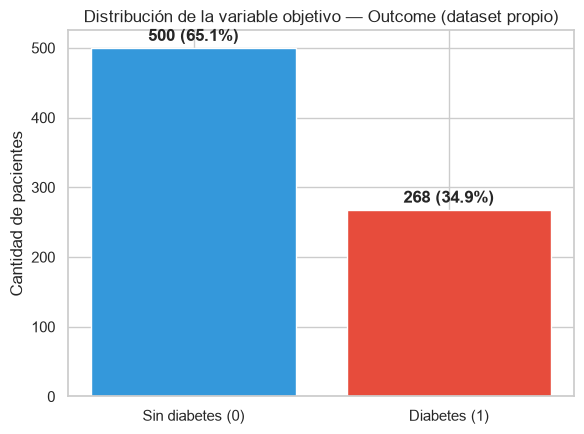


Ratio de desbalance: 1.9:1 (Sin diabetes vs Diabetes)


In [36]:
# 3.2  Distribución de la variable objetivo (Outcome)
print('Distribución de la variable objetivo (Outcome):')
print(df2['Outcome'].value_counts().sort_index())

counts2 = df2['Outcome'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(['Sin diabetes (0)', 'Diabetes (1)'], counts2.values, color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts2.values):
    ax.text(i, v + 10, f'{v} ({v/len(df2)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Distribución de la variable objetivo — Outcome (dataset propio)')
ax.set_ylabel('Cantidad de pacientes')
plt.tight_layout()
plt.show()

features2 = df2.columns.drop('Outcome')
print(f'\nRatio de desbalance: {counts2[0]/counts2[1]:.1f}:1 (Sin diabetes vs Diabetes)')

### 3.3  Análisis exploratorio orientado a clasificación (dataset propio)

In [38]:
# 3.3.1  Estadísticas descriptivas por clase
comparison2 = df2.groupby('Outcome')[features2].mean().T
comparison2.columns = ['Sin diabetes (0)', 'Diabetes (1)']
comparison2['Diferencia %'] = (
    (comparison2['Diabetes (1)'] - comparison2['Sin diabetes (0)']) / comparison2['Sin diabetes (0)'] * 100
).round(1)
comparison2.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,Sin diabetes (0),Diabetes (1),Diferencia %
Pregnancies,3.298000,4.865672,47.500000
Glucose,109.980000,141.257463,28.400000
BloodPressure,68.184000,70.824627,3.900000
SkinThickness,19.664000,22.164179,12.700000
Insulin,68.792000,100.335821,45.900000
BMI,30.304200,35.142537,16.000000
DiabetesPedigreeFunction,0.429734,0.550500,28.100000
Age,31.190000,37.067164,18.800000


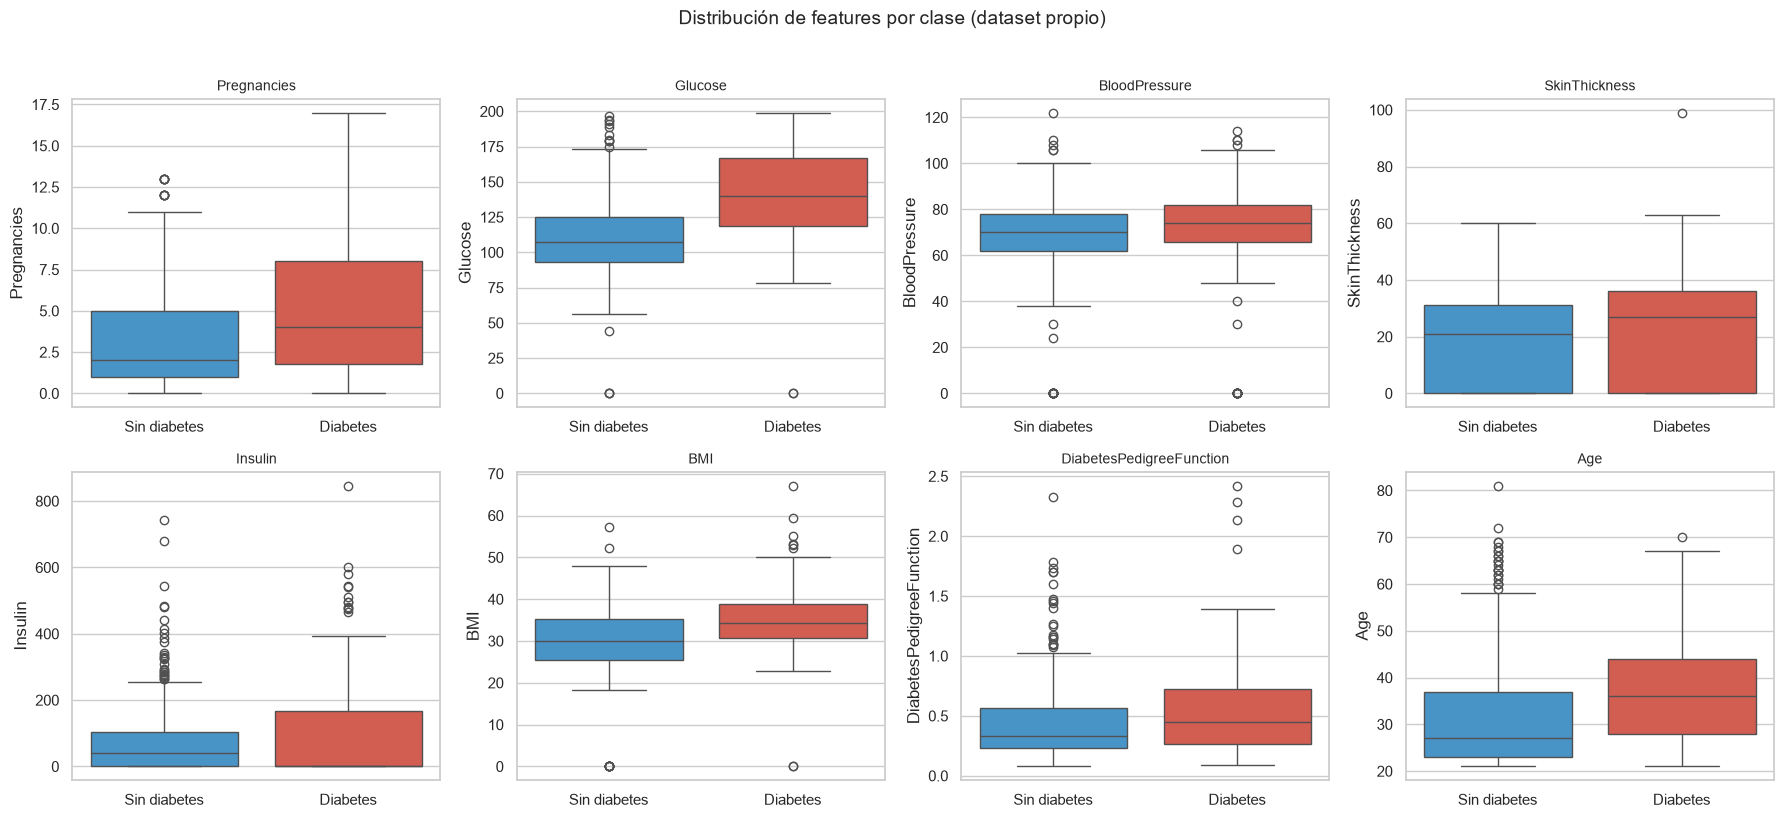

In [39]:
# 3.3.2  Distribución de features por clase (boxplots)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features2):
    sns.boxplot(data=df2, x='Outcome', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='Outcome', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Sin diabetes', 'Diabetes'])

fig.suptitle('Distribución de features por clase (dataset propio)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

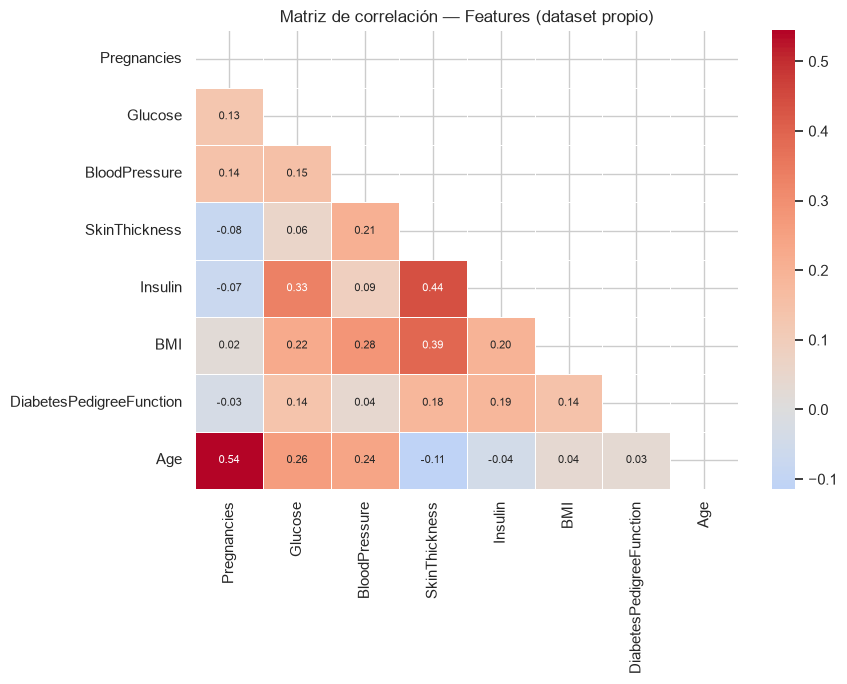

In [40]:
# 3.3.3  Correlación entre features
plt.figure(figsize=(9, 7))
corr2 = df2[features2].corr()
mask2 = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(corr2, mask=mask2, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features (dataset propio)')
plt.tight_layout()
plt.show()

### 3.4  Preparación de datos (dataset propio)

In [41]:
# 3.4.1  Separación features / target y split estratificado 80/20
X2 = df2[features2].copy()
y2 = df2['Outcome'].copy()

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.20, random_state=RANDOM_STATE, stratify=y2
)

print(f'Train: {X_train2.shape[0]} muestras  |  Test: {X_test2.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train2.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test2.mean():.3f}')

cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: 614 muestras  |  Test: 154 muestras
Proporción clase 1 en train: 0.349
Proporción clase 1 en test:  0.351


### 3.5  Modelo 1 — Regresión Logística (dataset propio)

In [42]:
# 3.5.1  Pipeline con estandarización
pipe_lr2 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])

scores_lr2 = cross_val_score(pipe_lr2, X_train2, y_train2, cv=cv2, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr2.mean():.4f} ± {scores_lr2.std():.4f}')

pipe_lr2.fit(X_train2, y_train2)
y_pred_lr2 = pipe_lr2.predict(X_test2)

Logistic Regression — F1 CV: 0.6779 ± 0.0194


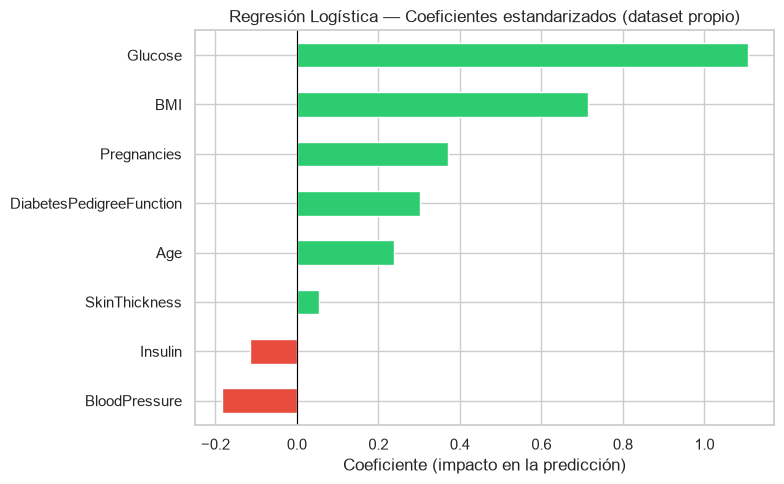

In [43]:
# 3.5.2  Coeficientes del modelo (interpretabilidad)
coefs2 = pd.Series(
    pipe_lr2.named_steps['clf'].coef_[0],
    index=features2
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors2 = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs2.values]
coefs2.plot(kind='barh', ax=ax, color=colors2)
ax.set_title('Regresión Logística — Coeficientes estandarizados (dataset propio)')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### 3.6  Modelo 2 — Árbol de Decisión (dataset propio)

In [44]:
# 3.6.1  Pipeline (no requiere estandarización)
pipe_dt2 = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt2 = cross_val_score(pipe_dt2, X_train2, y_train2, cv=cv2, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt2.mean():.4f} ± {scores_dt2.std():.4f}')

pipe_dt2.fit(X_train2, y_train2)
y_pred_dt2 = pipe_dt2.predict(X_test2)

Decision Tree — F1 CV: 0.6115 ± 0.0400


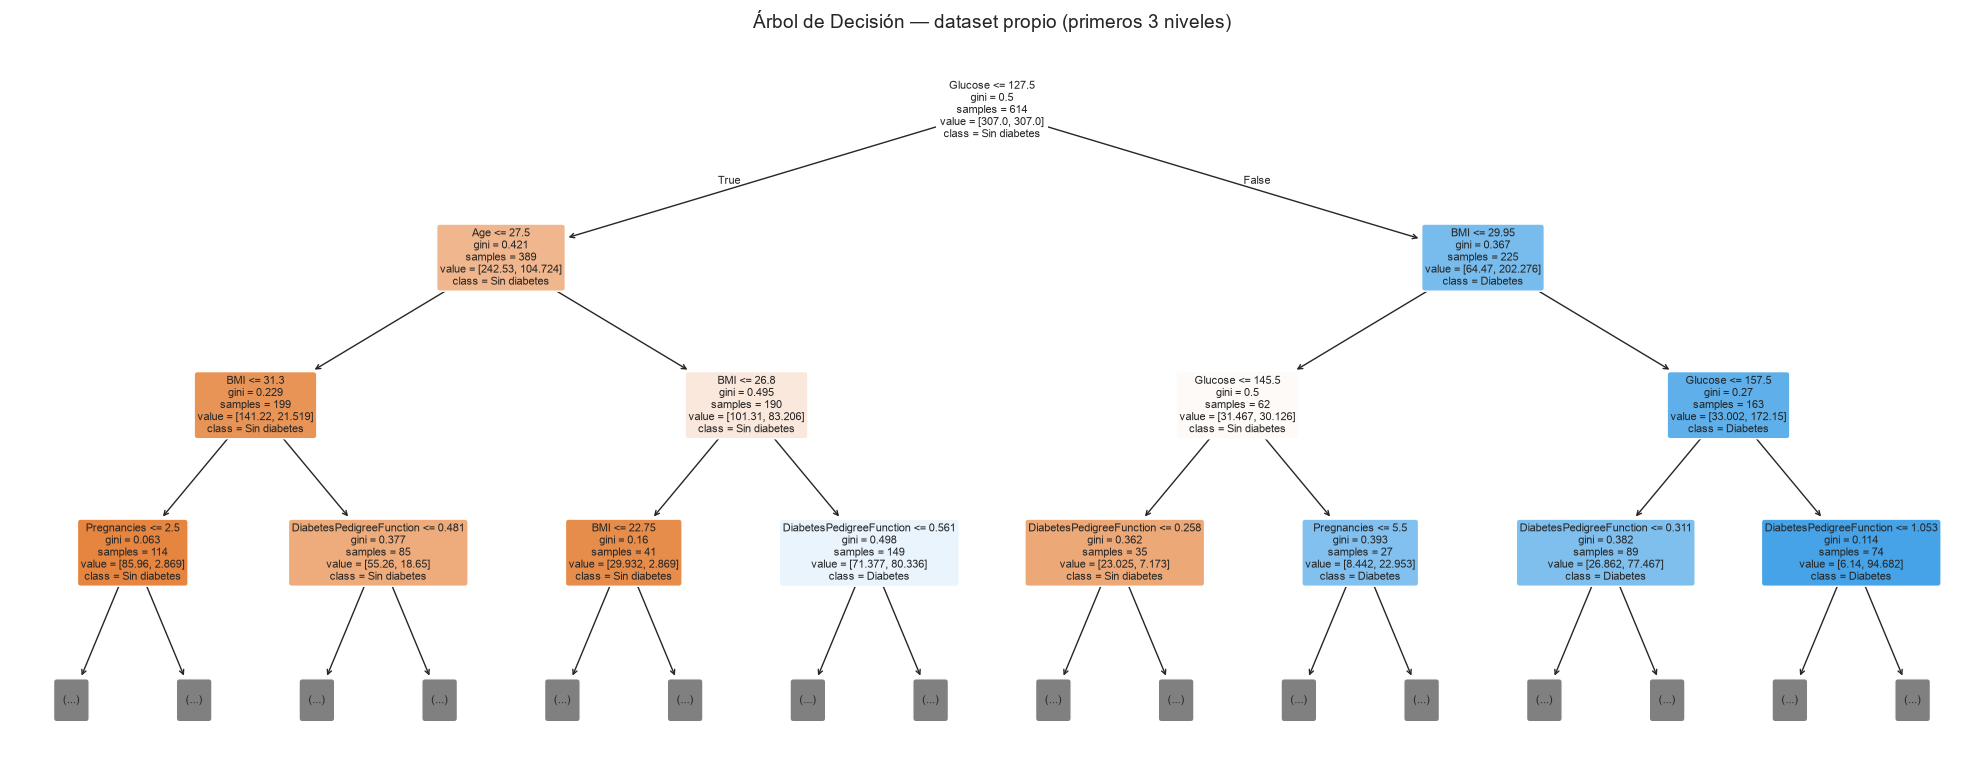

In [45]:
# 3.6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt2.named_steps['clf'],
    feature_names=list(features2),
    class_names=['Sin diabetes', 'Diabetes'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3
)
ax.set_title('Árbol de Decisión — dataset propio (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

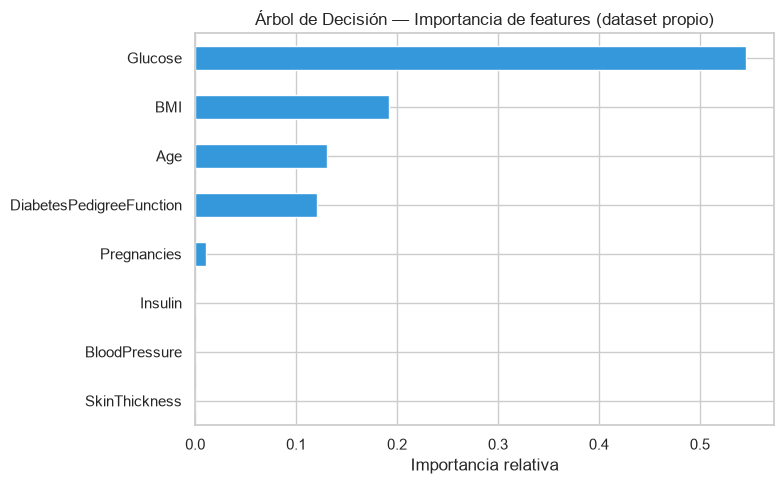

In [46]:
# 3.6.3  Importancia de features (Gini importance)
importances2 = pd.Series(
    pipe_dt2.named_steps['clf'].feature_importances_,
    index=features2
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances2.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (dataset propio)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

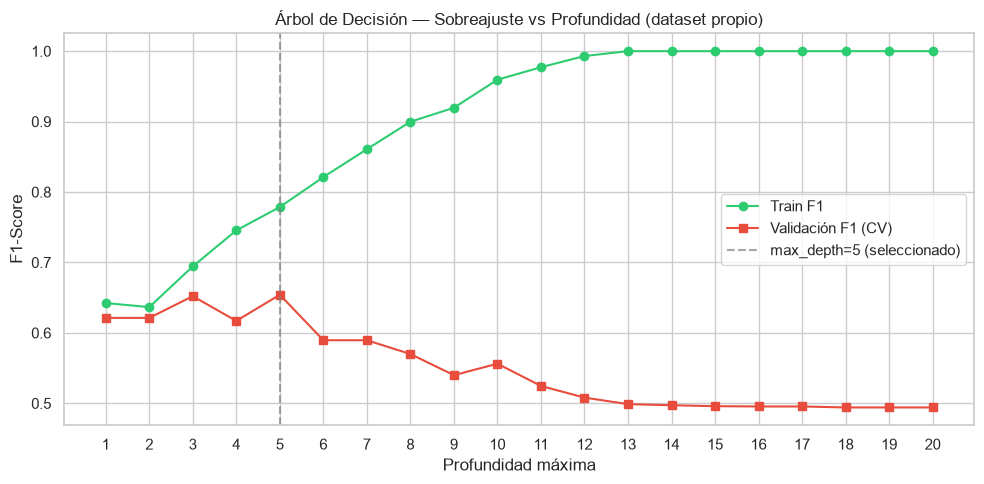

In [47]:
# 3.6.4  Efecto de la profundidad en sobreajuste/subajuste
depths2 = range(1, 21)
train_scores2 = []
val_scores2 = []

for d in depths2:
    dt2 = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=RANDOM_STATE)
    dt2.fit(X_train2, y_train2)
    train_scores2.append(f1_score(y_train2, dt2.predict(X_train2)))
    cv_s2 = cross_val_score(dt2, X_train2, y_train2, cv=cv2, scoring='f1')
    val_scores2.append(cv_s2.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths2, train_scores2, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths2, val_scores2, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad (dataset propio)')
ax.legend()
ax.set_xticks(depths2)
plt.tight_layout()
plt.show()

### 3.7  Modelo 3 — Support Vector Machine (dataset propio)

In [48]:
# 3.7.1  Comparación de kernels
kernels2 = ['linear', 'rbf', 'poly']
svm_results2 = {}

for kernel in kernels2:
    pipe_svm_tmp2 = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm_tmp2, X_train2, y_train2, cv=cv2, scoring='f1')
    svm_results2[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

best_kernel2 = max(svm_results2, key=lambda k: svm_results2[k].mean())
print(f'\nMejor kernel: {best_kernel2}')

SVM (linear) — F1 CV: 0.6756 ± 0.0224
SVM (rbf   ) — F1 CV: 0.6603 ± 0.0182
SVM (poly  ) — F1 CV: 0.5944 ± 0.0666

Mejor kernel: linear


In [49]:
# 3.7.2  Entrenamiento con el mejor kernel
pipe_svm2 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel2, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm2.fit(X_train2, y_train2)
y_pred_svm2 = pipe_svm2.predict(X_test2)
scores_svm2 = svm_results2[best_kernel2]

In [50]:
# 3.7.3  Impacto de la estandarización en SVM
svm_no_scale2 = SVC(kernel=best_kernel2, class_weight='balanced', random_state=RANDOM_STATE)
scores_no_scale2 = cross_val_score(svm_no_scale2, X_train2, y_train2, cv=cv2, scoring='f1')

print('Impacto de la estandarización en SVM (dataset propio):')
print(f'  CON StandardScaler: F1 = {scores_svm2.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale2.mean():.4f}')
print(f'  Diferencia: {(scores_svm2.mean() - scores_no_scale2.mean())*100:+.2f} puntos porcentuales')

Impacto de la estandarización en SVM (dataset propio):
  CON StandardScaler: F1 = 0.6756
  SIN StandardScaler: F1 = 0.6754
  Diferencia: +0.01 puntos porcentuales


### 3.8  Modelo 4 — K-Nearest Neighbors (dataset propio)

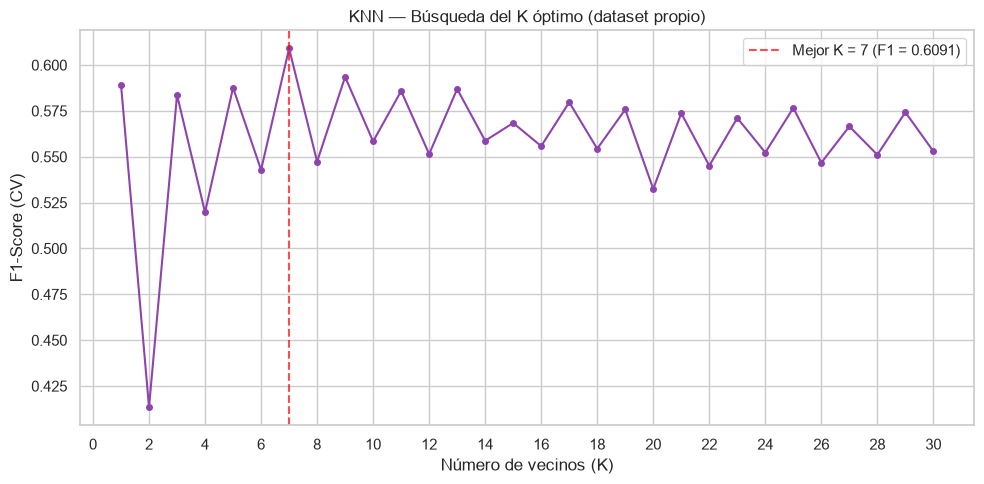

K óptimo: 7


In [51]:
# 3.8.1  Búsqueda del K óptimo
k_range2 = range(1, 31)
k_scores2 = []

for k in k_range2:
    pipe_knn_tmp2 = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn_tmp2, X_train2, y_train2, cv=cv2, scoring='f1')
    k_scores2.append(scores.mean())

best_k2 = k_range2[np.argmax(k_scores2)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range2, k_scores2, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k2, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k2} (F1 = {max(k_scores2):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo (dataset propio)')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k2}')

In [52]:
# 3.8.2  Entrenamiento con K óptimo
pipe_knn2 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k2))
])

scores_knn2 = cross_val_score(pipe_knn2, X_train2, y_train2, cv=cv2, scoring='f1')
print(f'KNN (K={best_k2}) — F1 CV: {scores_knn2.mean():.4f} ± {scores_knn2.std():.4f}')

pipe_knn2.fit(X_train2, y_train2)
y_pred_knn2 = pipe_knn2.predict(X_test2)

KNN (K=7) — F1 CV: 0.6091 ± 0.0633


### 3.9  Análisis comparativo de modelos (dataset propio)

In [53]:
# 3.9.1  Tabla resumen
models2 = {
    'Logistic Regression': (pipe_lr2, y_pred_lr2, scores_lr2),
    'Decision Tree':       (pipe_dt2, y_pred_dt2, scores_dt2),
    f'SVM ({best_kernel2})': (pipe_svm2, y_pred_svm2, scores_svm2),
    f'KNN (K={best_k2})':   (pipe_knn2, y_pred_knn2, scores_knn2)
}

summary2 = []
for name, (pipe, y_pred, cv_scores) in models2.items():
    summary2.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test2, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test2, y_pred):.4f}'
    })

summary_df2 = pd.DataFrame(summary2)
print('='*80)
print('COMPARACIÓN DE MODELOS — DATASET PROPIO (Pima Indians Diabetes, Kaggle)')
print('='*80)
summary_df2

COMPARACIÓN DE MODELOS — DATASET PROPIO (Pima Indians Diabetes, Kaggle)


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.6779,0.0194,0.7338,0.6496
1,Decision Tree,0.6115,0.0400,0.6948,0.6240
2,SVM (linear),0.6756,0.0224,0.7532,0.6724
3,KNN (K=7),0.6091,0.0633,0.7468,0.6139


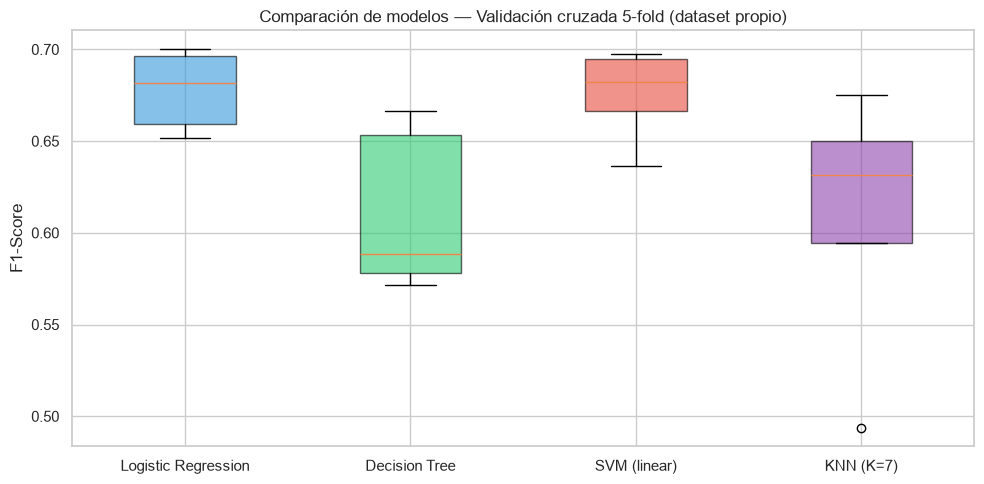

In [54]:
# 3.9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data2 = [scores_lr2, scores_dt2, scores_svm2, scores_knn2]
labels2 = list(models2.keys())
bp2 = ax.boxplot(cv_data2, tick_labels=labels2, patch_artist=True)
colors_box2 = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp2['boxes'], colors_box2):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada 5-fold (dataset propio)')
plt.tight_layout()
plt.show()

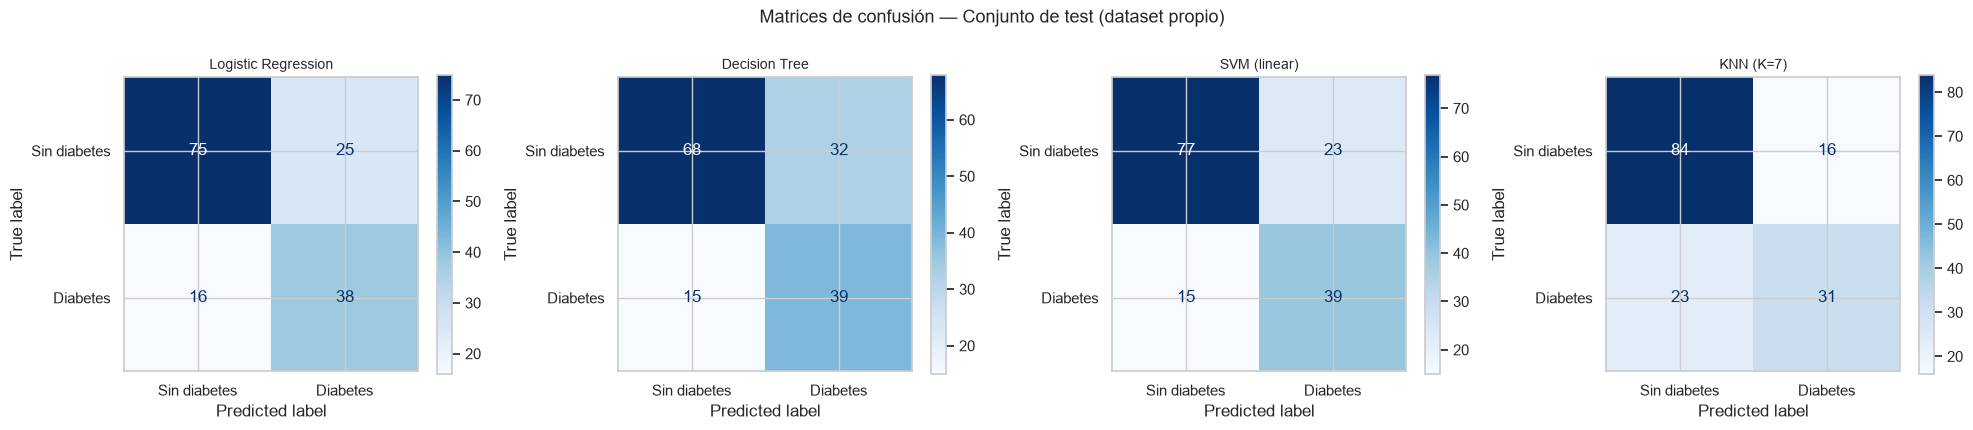

In [56]:
# 3.9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models2.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test2, y_pred,
        display_labels=['Sin diabetes', 'Diabetes'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test (dataset propio)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

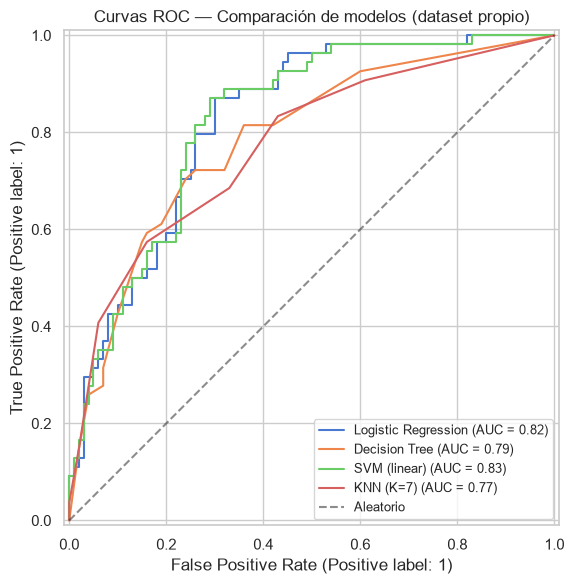

In [57]:
# 3.9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models2.items():
    RocCurveDisplay.from_estimator(pipe, X_test2, y_test2, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos (dataset propio)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [58]:
# 3.9.5  Classification report detallado del mejor modelo
best_model_name2 = max(models2, key=lambda k: float(models2[k][2].mean()))
best_pipe2, best_pred2, best_cv2 = models2[best_model_name2]

print(f'\nMejor modelo (dataset propio): {best_model_name2}')
print('='*60)
print(classification_report(y_test2, best_pred2, target_names=['Sin diabetes', 'Diabetes']))


Mejor modelo (dataset propio): Logistic Regression
              precision    recall  f1-score   support

Sin diabetes       0.82      0.75      0.79       100
    Diabetes       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



### 3.10  Hallazgos — Ejercicio 3

- El desbalance en Pima Indians Diabetes (~65%/35%, ratio ≈1.9:1) es **más moderado** que el del Wine Quality de la sesión (≈86%/14%, ratio ≈6:1), por lo que aquí `class_weight='balanced'` tiene un efecto correctivo menos drástico, aunque sigue mejorando el recall de la clase minoritaria ("Diabetes") frente a no usarlo.
- A diferencia del SVM en el dataset de vino (sensible a la escala), aquí la diferencia entre usar o no `StandardScaler` en SVM es **mucho menor**, porque las variables de Pima ya están en rangos numéricos más parecidos entre sí (a excepción de `Insulin`, que sigue mostrando algo de asimetría). Esto ilustra que el impacto del escalado depende de cuán dispares sean las magnitudes originales de cada dataset.
- El **Árbol de Decisión** vuelve a mostrar la curva esperada: el F1 de entrenamiento sube con la profundidad mientras el F1 de validación se estanca o cae levemente, evidenciando sobreajuste a partir de profundidades intermedias — el mismo patrón estructural que en la Sección 6, aunque con magnitudes distintas.
- Por interpretabilidad, los coeficientes de la Regresión Logística confirman lo que la literatura médica ya documenta: `Glucose`, `BMI` y `Age` (junto con `Pregnancies`) son históricamente los predictores más fuertes de diabetes en este dataset — coherente con la tabla de diferencias porcentuales por clase de la Sección 3.3.1.
- **Conclusión metodológica:** aunque el dominio cambió por completo (vino → salud), el mismo pipeline (EDA → preparación → 4 modelos con `Pipeline` + `StandardScaler` donde corresponde → validación cruzada estratificada → comparación con boxplot, matrices de confusión, ROC y `classification_report`) se reutilizó **sin modificar su lógica interna**, cambiando únicamente los nombres de columnas y las etiquetas de clase — que es precisamente el valor de construir un flujo de trabajo modular y reproducible.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*